In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
import yaml
try:
    with open("../config.yaml", "r") as file:
        cfg=yaml.safe_load(file)
except:
    print("Yaml configuration file not found!")

In [3]:
from pathlib import Path
GRAPH_DIR = Path("../data/graphs")
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
def save(fig, name, dpi=300):fig.savefig(
        GRAPH_DIR / f"{name}.png",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white")

In [4]:
# set color and style for graphs

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#0f1117',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#cccccc',
    'xtick.color':      '#cccccc',
    'ytick.color':      '#cccccc',
    'text.color':       '#ffffff',
    'grid.color':       '#222222',
    'grid.linewidth':   0.5,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#333333',
    'font.family':      'DejaVu Sans'})

TICKER_COLORS = {
    'NVDA': '#76b900',  
    'AMD':  '#ed1c24',  
    'INTC': '#0071c5',  
    'AVGO': '#ff6f00',  
    'QCOM': '#9c27b0', 
    'TXN':  '#00897b',  
    'MU':   '#00bcd4',  
    'ADI':  '#f06292', 
    'NXPI': '#fdd835',
    'MRVL': '#8d6e63'}


In [5]:
df = pd.read_csv(cfg['clean']['semiconductor_quarterly'])
df['quarter_end'] = pd.to_datetime(df['quarter_end'])
df = df.sort_values(['ticker', 'quarter_end']).reset_index(drop=True)
fe = df.copy()

In [6]:
fe.columns

Index(['ticker', 'company', 'quarter_end', 'fiscal_quarter_label', 'revenue_q',
       'gross_profit_q', 'ebit_q', 'net_income_q', 'rd_expense_q',
       'operating_cf_q', 'capex_q', 'cash_q', 'total_equity_q', 'total_debt_q',
       'da_q', 'ebitda_q', 'close_price', 'shares_outstanding', 'market_cap',
       'free_cash_flow_q', 'revenue_ttm', 'gross_profit_ttm', 'ebit_ttm',
       'net_income_ttm', 'rd_ttm', 'capex_ttm', 'operating_cf_ttm',
       'free_cash_flow_ttm', 'ebitda_ttm', 'gross_margin', 'operating_margin',
       'ebitda_margin', 'net_margin', 'avg_equity_ttm', 'roe', 'rd_to_revenue',
       'capex_to_revenue', 'debt_to_ebitda', 'revenue_growth_yoy',
       'ebitda_growth_yoy', 'net_income_growth_yoy', 'enterprise_value',
       'pe_ratio', 'ev_to_ebitda', 'price_to_sales'],
      dtype='str')

In [7]:
fe.ticker.value_counts()

ticker
ADI     18
AVGO    18
MRVL    18
MU      18
NVDA    18
AMD     17
INTC    17
NXPI    17
QCOM    17
TXN     17
Name: count, dtype: int64

# 1. New and transformed features

The core idea: we want to predict next quarter's market cap using LAST quarter's financial data. This prevents target leakage if we used this quarter's revenue to predict this quarter's market cap, the model would be cheating (it wouldn't have that data in a real prediction scenario).

In [8]:
# use statsmodels.tsa.stattools.acf to check which lag is more significant:

from statsmodels.tsa.stattools import acf

lag_cols = ['revenue_ttm', 'ebitda_ttm', 'net_income_ttm', 'free_cash_flow_ttm',
    'gross_margin', 'operating_margin', 'ebitda_margin', 'net_margin',
    'revenue_growth_yoy', 'ebitda_growth_yoy', 'net_income_growth_yoy',
    'roe', 'rd_to_revenue', 'capex_to_revenue', 'debt_to_ebitda']

max_lag = 8

results = []

for col in lag_cols:

    ticker_acfs = []

    for ticker, group in fe.groupby('ticker'):

        series = (group.sort_values('quarter_end')[col].dropna())

        if len(series) > max_lag:
            acf_vals = acf(series, nlags=max_lag)

            ticker_acfs.append(acf_vals)

    if ticker_acfs:
        mean_acf = np.mean(ticker_acfs, axis=0)

        results.append({
            'Variable': col,
            **{f'Lag {i}': mean_acf[i] for i in range(max_lag + 1)}})

acf_summary = (pd.DataFrame(results).set_index('Variable').round(3))

print(acf_summary)

                       Lag 0  Lag 1  Lag 2  Lag 3  Lag 4  Lag 5  Lag 6  Lag 7  \
Variable                                                                        
revenue_ttm              1.0  0.722  0.493  0.259  0.049 -0.087 -0.208 -0.260   
ebitda_ttm               1.0  0.725  0.456  0.194 -0.014 -0.143 -0.239 -0.261   
net_income_ttm           1.0  0.708  0.404  0.144 -0.060 -0.162 -0.200 -0.203   
free_cash_flow_ttm       1.0  0.685  0.423  0.211  0.016 -0.055 -0.106 -0.167   
gross_margin             1.0  0.779  0.471  0.161 -0.085 -0.223 -0.284 -0.272   
operating_margin         1.0  0.729  0.435  0.123 -0.114 -0.245 -0.292 -0.275   
ebitda_margin            1.0  0.760  0.466  0.156 -0.078 -0.201 -0.267 -0.267   
net_margin               1.0  0.743  0.420  0.116 -0.120 -0.236 -0.264 -0.240   
revenue_growth_yoy       1.0  0.579  0.292  0.048 -0.227 -0.227 -0.215 -0.222   
ebitda_growth_yoy        1.0  0.374  0.083 -0.069 -0.125 -0.194 -0.187 -0.180   
net_income_growth_yoy    1.0

Lag1 confirmed to have the strongest autocorrelation and therefore be a better predictor for next quarters values. No evidence of a seasonal peak at lag 4 indicating that previous-quarter values provide substantially more information than observations from the same quarter in the previous year.

In [9]:
lag_cols = [
    'revenue_ttm', 'ebitda_ttm', 'net_income_ttm', 'free_cash_flow_ttm',
    'gross_margin', 'operating_margin', 'ebitda_margin', 'net_margin',
    'revenue_growth_yoy', 'ebitda_growth_yoy', 'net_income_growth_yoy',
    'roe', 'rd_to_revenue', 'capex_to_revenue', 'debt_to_ebitda']

for col in lag_cols:
    fe[f'{col}_lag1'] = fe.groupby('ticker')[col].shift(1)
 
print(f" Lag-1 features created: {len(lag_cols)} new columns")

 Lag-1 features created: 15 new columns


**NO LONGER DOINF THIS LOG TRANSFORMATION: will use the powertransformer after split**

In [10]:
# LOG transformation on financial features:

fe['log_revenue_ttm_lag1']= np.log(fe['revenue_ttm_lag1'].clip(lower=1))
fe['log_ebitda_ttm_lag1']= np.log(fe['ebitda_ttm_lag1'].clip(lower=1))
fe['log_free_cash_flow_ttm_lag1']= np.log(fe['free_cash_flow_ttm_lag1'].clip(lower=1))

In [11]:
# CYCLICAL QUARTER ENCODING
# semiconductor revenue is seasonal: Q4 tends to be strong (holiday electronics),Q1 tends to be softer. A plain number (1, 2, 3, 4) implies Q4 and Q1 are farapart but they are adjacent in the cycle.
# sin/cos encoding wraps the quarters into a circle so Q4→Q1 is a small step.
 
fe['fiscal_q_num']= fe['quarter_end'].dt.quarter     
fe['quarter_sin']= np.sin(2 * np.pi * fe['fiscal_q_num'] / 4)
fe['quarter_cos']= np.cos(2 * np.pi * fe['fiscal_q_num'] / 4)
 
print(" Cyclical quarter encoding: quarter_sin, quarter_cos")

 Cyclical quarter encoding: quarter_sin, quarter_cos


In [12]:
# OHE for nominal categorical variable: ticker

ticker_dummies = pd.get_dummies(fe['ticker'], prefix='ticker', drop_first=True)
fe = pd.concat([fe, ticker_dummies], axis=1)
 
print(f"Ticker dummies: {ticker_dummies.shape[1]} columns (drop_first=True)")

Ticker dummies: 9 columns (drop_first=True)


In [13]:
print(f"Dataset after feature engineering: {fe.shape[0]} rows × {fe.shape[1]} cols")

Dataset after feature engineering: 175 rows × 75 cols


# 2. Define features

In [14]:
# transform target variable= market cap so it's more normal
pt = PowerTransformer(method='yeo-johnson')
fe['market_cap_pt'] = pt.fit_transform(fe[['market_cap']]).squeeze()

**Comparison Spearman vs Pearson correlation of all variables**

In [15]:
# SPEARMAN correlation of ALL numeric columns with  target
corr_all = {}
for col in fe.select_dtypes(include='number').columns:
    if col in ['market_cap']: 
        continue
    sub = fe[['market_cap', col]].dropna()
    if len(sub) > 10:
        r, _ = spearmanr(sub['market_cap'], sub[col])
        corr_all[col] = round(r, 3)

corr_all_series = pd.Series(corr_all).sort_values(key=abs, ascending=False)
print(corr_all_series.to_string())

market_cap_pt                  1.000
enterprise_value               0.973
shares_outstanding             0.693
revenue_q                      0.595
total_equity_q                 0.589
revenue_ttm                    0.575
pe_ratio                       0.570
gross_profit_q                 0.568
avg_equity_ttm                 0.563
revenue_ttm_lag1               0.562
log_revenue_ttm_lag1           0.562
gross_profit_ttm               0.532
price_to_sales                 0.527
rd_expense_q                   0.481
rd_ttm                         0.477
ebitda_q                       0.467
operating_cf_q                 0.451
da_q                           0.447
operating_cf_ttm               0.445
debt_to_ebitda                -0.436
ebitda_ttm                     0.436
ev_to_ebitda                   0.422
debt_to_ebitda_lag1           -0.413
ebitda_ttm_lag1                0.402
log_ebitda_ttm_lag1            0.402
capex_q                        0.394
close_price                    0.380
c

In [16]:
# PEARSON correlation of ALL numeric columns with transformed target
corr_all = {}
for col in fe.select_dtypes(include='number').columns:
    if col in ['market_cap', 'market_cap_pt']:  # skip target and raw target
        continue
    sub = fe[['market_cap_pt', col]].dropna()
    if len(sub) > 10:
        r, _ = pearsonr(sub['market_cap_pt'], sub[col])
        corr_all[col] = round(r, 3)

corr_all_series = pd.Series(corr_all).sort_values(key=abs, ascending=False)
print(corr_all_series.to_string())

price_to_sales                 0.681
enterprise_value               0.632
revenue_ttm                    0.607
revenue_q                      0.605
revenue_ttm_lag1               0.603
gross_profit_ttm               0.583
shares_outstanding             0.582
log_revenue_ttm_lag1           0.580
total_equity_q                 0.580
gross_profit_q                 0.580
operating_cf_ttm               0.556
ebitda_ttm                     0.555
ebitda_ttm_lag1                0.550
ebitda_q                       0.547
avg_equity_ttm                 0.535
operating_cf_q                 0.526
rd_expense_q                   0.521
ebit_ttm                       0.519
ebit_q                         0.518
net_income_ttm                 0.508
net_income_q                   0.500
net_income_ttm_lag1            0.497
rd_ttm                         0.490
free_cash_flow_ttm             0.471
free_cash_flow_q               0.465
free_cash_flow_ttm_lag1        0.462
close_price                    0.416
c

In [17]:
# create a feature selection df dropping the columns we already we won't be using: those used to calculate market cap, all quarterly values with a ttm option and all price related ratios

drop_cols = ['company','revenue_q','gross_profit_q','ebit_q','net_income_q','rd_expense_q','operating_cf_q','capex_q',
    'cash_q','total_equity_q','total_debt_q','da_q','ebitda_q','close_price','shares_outstanding',
    'free_cash_flow_q','revenue_ttm','gross_profit_ttm','ebit_ttm','net_income_ttm','rd_ttm','capex_ttm',
    'operating_cf_ttm','free_cash_flow_ttm','ebitda_ttm','gross_margin','operating_margin','ebitda_margin',
    'net_margin','avg_equity_ttm','roe','rd_to_revenue','capex_to_revenue','debt_to_ebitda','revenue_growth_yoy',
    'ebitda_growth_yoy','net_income_growth_yoy','enterprise_value','pe_ratio','ev_to_ebitda','price_to_sales']

fs = fe.drop(columns=drop_cols, errors='ignore')

print(f"Dropped {len(drop_cols)} columns.")
print(f"Remaining columns: {fs.shape[1]}")
print(fs.columns.tolist())

Dropped 41 columns.
Remaining columns: 35
['ticker', 'quarter_end', 'fiscal_quarter_label', 'market_cap', 'revenue_ttm_lag1', 'ebitda_ttm_lag1', 'net_income_ttm_lag1', 'free_cash_flow_ttm_lag1', 'gross_margin_lag1', 'operating_margin_lag1', 'ebitda_margin_lag1', 'net_margin_lag1', 'revenue_growth_yoy_lag1', 'ebitda_growth_yoy_lag1', 'net_income_growth_yoy_lag1', 'roe_lag1', 'rd_to_revenue_lag1', 'capex_to_revenue_lag1', 'debt_to_ebitda_lag1', 'log_revenue_ttm_lag1', 'log_ebitda_ttm_lag1', 'log_free_cash_flow_ttm_lag1', 'fiscal_q_num', 'quarter_sin', 'quarter_cos', 'ticker_AMD', 'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL', 'ticker_MU', 'ticker_NVDA', 'ticker_NXPI', 'ticker_QCOM', 'ticker_TXN', 'market_cap_pt']


In [18]:
ticker_cols = ['ticker_AMD', 'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL',
    'ticker_MU', 'ticker_NVDA', 'ticker_NXPI', 'ticker_QCOM','ticker_TXN']

corr = (fs[ticker_cols + ['market_cap_pt']]
    .corr(method='spearman')['market_cap_pt']
    .drop('market_cap_pt')
    .sort_values(ascending=False)
    .to_frame(name='spearman_r'))

print(corr)

             spearman_r
ticker_AMD     0.304414
ticker_QCOM    0.183336
ticker_TXN     0.179899
ticker_NVDA    0.139266
ticker_INTC    0.111147
ticker_MU     -0.028300
ticker_AVGO   -0.061813
ticker_MRVL   -0.336249
ticker_NXPI   -0.389971


In [19]:
ticker_cols = ['ticker_AMD', 'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL',
    'ticker_MU', 'ticker_NVDA', 'ticker_NXPI', 'ticker_QCOM','ticker_TXN']

corr = (fs[ticker_cols + ['market_cap_pt']]
    .corr(method='pearson')['market_cap_pt']
    .drop('market_cap_pt')
    .sort_values(ascending=False)
    .to_frame(name='pearson_r'))

print(corr)

             pearson_r
ticker_NVDA   0.235074
ticker_AMD    0.201490
ticker_TXN    0.120579
ticker_QCOM   0.119071
ticker_INTC   0.079597
ticker_MU     0.008499
ticker_AVGO  -0.104066
ticker_MRVL  -0.281752
ticker_NXPI  -0.330909


In [20]:
# we have our lagged features-> re-evaluate which ones actually correlate with the Yeo-Johnson transformed target

pt = PowerTransformer(method='yeo-johnson')
fs['market_cap_pt'] = pt.fit_transform(fs[['market_cap']]).squeeze()

candidate_features = ['revenue_ttm_lag1','ebitda_ttm_lag1','net_income_ttm_lag1','free_cash_flow_ttm_lag1','gross_margin_lag1',
                      'operating_margin_lag1','ebitda_margin_lag1','net_margin_lag1','revenue_growth_yoy_lag1','ebitda_growth_yoy_lag1',
                      'net_income_growth_yoy_lag1','roe_lag1','rd_to_revenue_lag1','capex_to_revenue_lag1','debt_to_ebitda_lag1',
                      'log_revenue_ttm_lag1','log_ebitda_ttm_lag1','log_free_cash_flow_ttm_lag1','fiscal_q_num','quarter_sin','quarter_cos']

YE0–JOHNSON TRANSFORMATION OF MARKET CAP


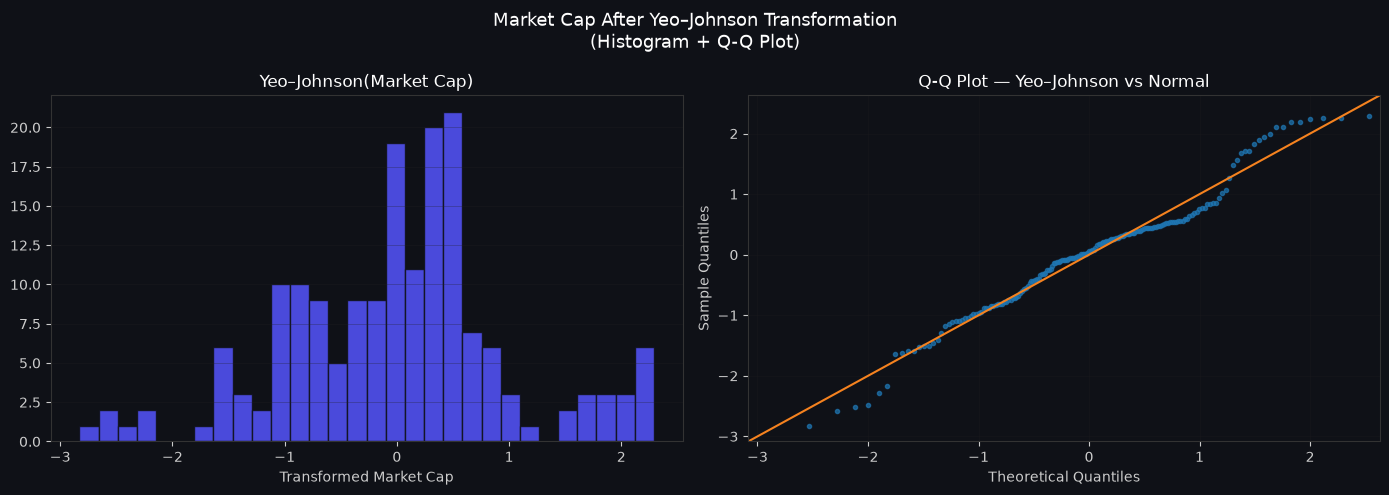


KS test after Yeo–Johnson transformation:
  KS statistic: 0.0929
  p-value: 0.091342
  -> Q-Q plot shows how close distribution is to normal
  -> Yeo–Johnson handles zeros/negatives better than log


In [21]:
print("YE0–JOHNSON TRANSFORMATION OF MARKET CAP")

mc = fs['market_cap'].dropna()

pt = PowerTransformer(method='yeo-johnson')
mc_pt = pt.fit_transform(mc.values.reshape(-1, 1)).ravel()

mc_pt_std = (mc_pt - mc_pt.mean()) / mc_pt.std()

ks_stat_pt, ks_p_pt = stats.kstest(mc_pt_std, 'norm')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Market Cap After Yeo–Johnson Transformation\n(Histogram + Q-Q Plot)', fontsize=13)

# histogram
axes[0].hist(mc_pt, bins=30, color='#5555ff', edgecolor='#0f1117', alpha=0.85)
axes[0].set_title('Yeo–Johnson(Market Cap)')
axes[0].set_xlabel('Transformed Market Cap')
axes[0].grid(axis='y', alpha=0.4)

# QQ plot
sm.qqplot(mc_pt, fit=True, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot — Yeo–Johnson vs Normal')
axes[1].get_lines()[0].set(color='#5555ff', markersize=3, alpha=0.7)
axes[1].get_lines()[1].set(color='#f5821f', lw=1.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
save(fig, '17_yeojohnson_normality')
plt.show()

print(f"\nKS test after Yeo–Johnson transformation:")
print(f"  KS statistic: {ks_stat_pt:.4f}")
print(f"  p-value: {ks_p_pt:.6f}")
print("  -> Q-Q plot shows how close distribution is to normal")
print("  -> Yeo–Johnson handles zeros/negatives better than log")

In [22]:
# SPEARMAN correlation

corr_sp_df = (
    fs[candidate_features]
    .corrwith(fs['market_cap'], method='spearman')
    .sort_values(key=abs, ascending=False)
    .reset_index())

corr_sp_df.columns = ['feature', 'spearman_r']

print(corr_sp_df.to_string(index=False))

                    feature  spearman_r
           revenue_ttm_lag1    0.562452
       log_revenue_ttm_lag1    0.562452
        debt_to_ebitda_lag1   -0.412697
            ebitda_ttm_lag1    0.401977
        log_ebitda_ttm_lag1    0.401908
        net_income_ttm_lag1    0.304977
log_free_cash_flow_ttm_lag1    0.258494
    free_cash_flow_ttm_lag1    0.256644
 net_income_growth_yoy_lag1    0.256320
    revenue_growth_yoy_lag1    0.253853
            net_margin_lag1    0.191109
      operating_margin_lag1    0.172069
         rd_to_revenue_lag1   -0.164278
      capex_to_revenue_lag1   -0.151941
                   roe_lag1    0.131352
          gross_margin_lag1    0.123990
     ebitda_growth_yoy_lag1    0.121656
         ebitda_margin_lag1    0.105615
               fiscal_q_num   -0.046762
                quarter_sin    0.032218
                quarter_cos   -0.023526


In [23]:
# pearson correlation of each candidate with transformed target

corr_per_df = (
    fs[candidate_features]
    .corrwith(fs['market_cap_pt'])
    .sort_values(key=abs, ascending=False)
    .reset_index())

corr_per_df.columns = ['feature', 'pearson_r']

print(corr_per_df.to_string(index=False))

                    feature  pearson_r
           revenue_ttm_lag1   0.602823
       log_revenue_ttm_lag1   0.579646
            ebitda_ttm_lag1   0.550103
        net_income_ttm_lag1   0.496736
    free_cash_flow_ttm_lag1   0.462244
    revenue_growth_yoy_lag1   0.314559
                   roe_lag1   0.267514
            net_margin_lag1   0.241938
      operating_margin_lag1   0.221971
         rd_to_revenue_lag1  -0.216674
         ebitda_margin_lag1   0.184851
        log_ebitda_ttm_lag1   0.175833
 net_income_growth_yoy_lag1   0.147056
          gross_margin_lag1   0.128697
     ebitda_growth_yoy_lag1   0.089469
      capex_to_revenue_lag1   0.050791
        debt_to_ebitda_lag1  -0.045796
               fiscal_q_num  -0.044191
                quarter_cos  -0.035955
log_free_cash_flow_ttm_lag1   0.029187
                quarter_sin   0.015424


In [24]:
# drop log features as they don't improve relation 

log_cols=['log_revenue_ttm_lag1','log_ebitda_ttm_lag1','log_free_cash_flow_ttm_lag1','fiscal_q_num','quarter_sin','quarter_cos']
candidate_features = [f for f in candidate_features if f not in log_cols]
fs = fs.drop(columns=log_cols, errors='ignore')

In [25]:
fs.columns

Index(['ticker', 'quarter_end', 'fiscal_quarter_label', 'market_cap',
       'revenue_ttm_lag1', 'ebitda_ttm_lag1', 'net_income_ttm_lag1',
       'free_cash_flow_ttm_lag1', 'gross_margin_lag1', 'operating_margin_lag1',
       'ebitda_margin_lag1', 'net_margin_lag1', 'revenue_growth_yoy_lag1',
       'ebitda_growth_yoy_lag1', 'net_income_growth_yoy_lag1', 'roe_lag1',
       'rd_to_revenue_lag1', 'capex_to_revenue_lag1', 'debt_to_ebitda_lag1',
       'ticker_AMD', 'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL', 'ticker_MU',
       'ticker_NVDA', 'ticker_NXPI', 'ticker_QCOM', 'ticker_TXN',
       'market_cap_pt'],
      dtype='str')

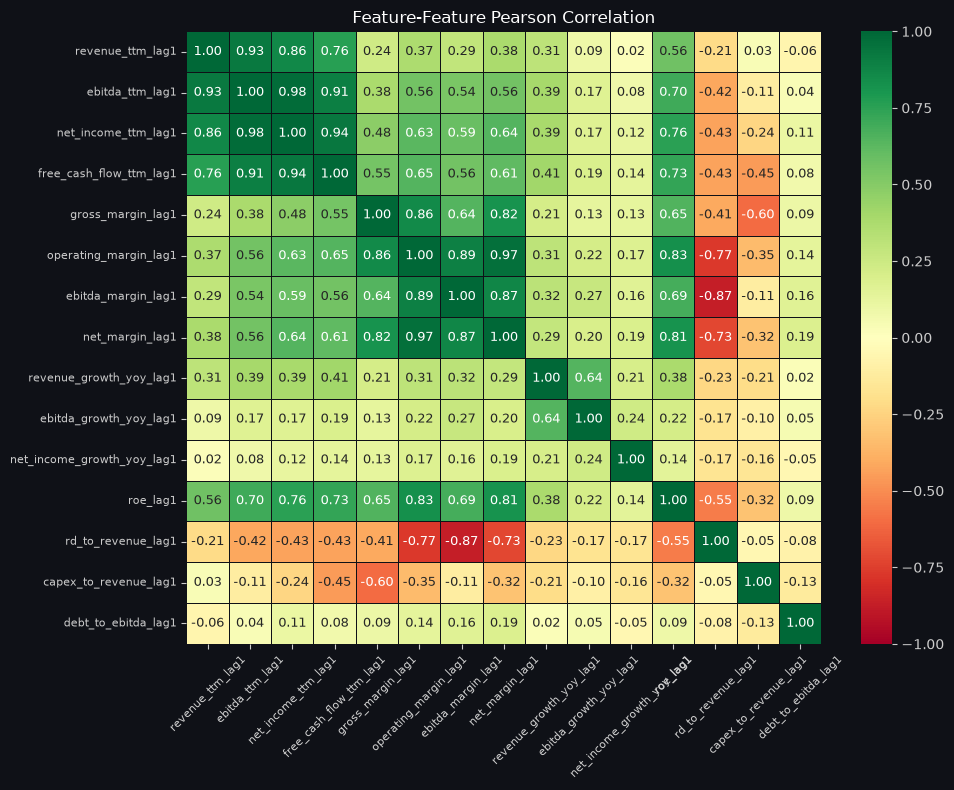

In [26]:
# correlation heatmap between candidate features: 

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = fs[candidate_features].corr(method='pearson')

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'size': 9},

            linewidths=0.5, linecolor='#0f1117')

ax.set_title('Feature-Feature Pearson Correlation', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
save(fig, '21c_feature_correlation_heatmap')
plt.show()

The main features related to the target variable are too correlated with each other so if we want to use linaer model there will be leakage

# 3. Multicollinearity

In [27]:
# VIF:

X = fs[candidate_features].dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)for i in range(X.shape[1])]

vif_data = vif_data.sort_values("VIF", ascending=False)

print(vif_data)

                       feature         VIF
1              ebitda_ttm_lag1  762.693584
2          net_income_ttm_lag1  351.226508
4            gross_margin_lag1  260.657188
5        operating_margin_lag1  212.721022
0             revenue_ttm_lag1  142.490891
6           ebitda_margin_lag1  110.585890
7              net_margin_lag1   93.370034
12          rd_to_revenue_lag1   78.050488
3      free_cash_flow_ttm_lag1   30.298864
11                    roe_lag1   14.120294
13       capex_to_revenue_lag1   12.434933
8      revenue_growth_yoy_lag1    2.859791
9       ebitda_growth_yoy_lag1    1.964558
14         debt_to_ebitda_lag1    1.293144
10  net_income_growth_yoy_lag1    1.159970


In [28]:
# VIF loop to keep eliminating any above 10 to see which features we can keep
def compute_vif(df):
    vif = pd.DataFrame()
    vif['feature'] = df.columns
    vif['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif.sort_values('VIF', ascending=False)

X_iter = X.copy()

while True:
    vif_df = compute_vif(X_iter)
    max_vif = vif_df.iloc[0]

    print(max_vif)

    if max_vif['VIF'] < 10:
        break

    print(f"Removing: {max_vif['feature']}")
    X_iter = X_iter.drop(columns=[max_vif["feature"]])

feature    ebitda_ttm_lag1
VIF             762.693584
Name: 1, dtype: object
Removing: ebitda_ttm_lag1
feature    gross_margin_lag1
VIF               232.674687
Name: 3, dtype: object
Removing: gross_margin_lag1
feature    operating_margin_lag1
VIF                    87.995288
Name: 3, dtype: object
Removing: operating_margin_lag1
feature    ebitda_margin_lag1
VIF                  35.50788
Name: 3, dtype: object
Removing: ebitda_margin_lag1
feature    net_income_ttm_lag1
VIF                  22.485817
Name: 1, dtype: object
Removing: net_income_ttm_lag1
feature    revenue_ttm_lag1
VIF               11.142389
Name: 0, dtype: object
Removing: revenue_ttm_lag1
feature    roe_lag1
VIF        7.855567
Name: 5, dtype: object


In [29]:
# final fetures

final_features = X_iter.columns.tolist()
print(final_features)
final_vif = compute_vif(X_iter)
print(final_vif)

['free_cash_flow_ttm_lag1', 'net_margin_lag1', 'revenue_growth_yoy_lag1', 'ebitda_growth_yoy_lag1', 'net_income_growth_yoy_lag1', 'roe_lag1', 'rd_to_revenue_lag1', 'capex_to_revenue_lag1', 'debt_to_ebitda_lag1']
                      feature       VIF
5                    roe_lag1  7.855567
1             net_margin_lag1  5.603431
0     free_cash_flow_ttm_lag1  3.231305
2     revenue_growth_yoy_lag1  2.389860
6          rd_to_revenue_lag1  1.935861
7       capex_to_revenue_lag1  1.849037
3      ebitda_growth_yoy_lag1  1.835487
4  net_income_growth_yoy_lag1  1.118697
8         debt_to_ebitda_lag1  1.071320


In [30]:
# correlation fo features with low enough VIF

target = "market_cap_pt"

corr_results = {}

for col in final_features:
    sub = fs[[target, col]].dropna()
    
    if len(sub) > 10:
        r, _ = spearmanr(sub[target], sub[col])
        corr_results[col] = r

corr_df = (
    pd.Series(corr_results)
    .sort_values(key=abs, ascending=False)
    .reset_index())

corr_df.columns = ["feature", "spearman_r"]

print(corr_df)

                      feature  spearman_r
0         debt_to_ebitda_lag1   -0.412697
1     free_cash_flow_ttm_lag1    0.256644
2  net_income_growth_yoy_lag1    0.256320
3     revenue_growth_yoy_lag1    0.253853
4             net_margin_lag1    0.191109
5          rd_to_revenue_lag1   -0.164278
6       capex_to_revenue_lag1   -0.151941
7                    roe_lag1    0.131352
8      ebitda_growth_yoy_lag1    0.121656


In [31]:
# correlation fo features with low enough VIF

target = "market_cap_pt"

corr_results = {}

for col in final_features:
    sub = fs[[target, col]].dropna()
    
    if len(sub) > 10:
        r, _ = pearsonr(sub[target], sub[col])
        corr_results[col] = r

corr_df = (pd.Series(corr_results)
    .sort_values(key=abs, ascending=False)
    .reset_index())

corr_df.columns = ["feature", "pearson_r"]

print(corr_df)

                      feature  pearson_r
0     free_cash_flow_ttm_lag1   0.462244
1     revenue_growth_yoy_lag1   0.314559
2                    roe_lag1   0.267514
3             net_margin_lag1   0.241938
4          rd_to_revenue_lag1  -0.216674
5  net_income_growth_yoy_lag1   0.147056
6      ebitda_growth_yoy_lag1   0.089469
7       capex_to_revenue_lag1   0.050791
8         debt_to_ebitda_lag1  -0.045796


# 4. Train test split

In [32]:
fs.columns

Index(['ticker', 'quarter_end', 'fiscal_quarter_label', 'market_cap',
       'revenue_ttm_lag1', 'ebitda_ttm_lag1', 'net_income_ttm_lag1',
       'free_cash_flow_ttm_lag1', 'gross_margin_lag1', 'operating_margin_lag1',
       'ebitda_margin_lag1', 'net_margin_lag1', 'revenue_growth_yoy_lag1',
       'ebitda_growth_yoy_lag1', 'net_income_growth_yoy_lag1', 'roe_lag1',
       'rd_to_revenue_lag1', 'capex_to_revenue_lag1', 'debt_to_ebitda_lag1',
       'ticker_AMD', 'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL', 'ticker_MU',
       'ticker_NVDA', 'ticker_NXPI', 'ticker_QCOM', 'ticker_TXN',
       'market_cap_pt'],
      dtype='str')

In [33]:
# select features for baseline lineal regression model

vif_features = ['free_cash_flow_ttm_lag1','net_margin_lag1','revenue_growth_yoy_lag1',
    'ebitda_growth_yoy_lag1','net_income_growth_yoy_lag1','roe_lag1',
    'rd_to_revenue_lag1','capex_to_revenue_lag1','debt_to_ebitda_lag1']


ticker_features = ['ticker_AMD', 'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL', 'ticker_MU',
       'ticker_NVDA', 'ticker_NXPI', 'ticker_QCOM', 'ticker_TXN']

# baseline dataframe
bl = fs[['ticker','quarter_end','market_cap'] + vif_features + ticker_features].copy()

print(bl.columns)
print(bl.shape)

Index(['ticker', 'quarter_end', 'market_cap', 'free_cash_flow_ttm_lag1',
       'net_margin_lag1', 'revenue_growth_yoy_lag1', 'ebitda_growth_yoy_lag1',
       'net_income_growth_yoy_lag1', 'roe_lag1', 'rd_to_revenue_lag1',
       'capex_to_revenue_lag1', 'debt_to_ebitda_lag1', 'ticker_AMD',
       'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL', 'ticker_MU', 'ticker_NVDA',
       'ticker_NXPI', 'ticker_QCOM', 'ticker_TXN'],
      dtype='str')
(175, 21)


In [34]:
target = bl['market_cap']
features= bl.drop(columns=['market_cap', 'ticker', 'quarter_end'])

In [35]:
feature_cols = vif_features + ticker_features
target_col = 'market_cap'
bl=bl.dropna(subset=feature_cols + [target_col])

In [36]:
# CHRONOLOGICAL TRAIN / TEST SPLIT
# test: last 4 quarters per ticker 
# train: everything before 

bl = bl.sort_values(['ticker', 'quarter_end'])

bl['rank'] = bl.groupby('ticker')['quarter_end'].rank(method='first', ascending=False)

train = bl[bl['rank'] > 4].copy()
test  = bl[bl['rank'] <= 4].copy()

# remove rows with missing feature values
train = train.dropna()
test = test.dropna()

In [37]:
print(f"CHRONOLOGICAL SPLIT")
print(f"Train:{train.shape[0]} rows;{train['quarter_end'].min().date()} -> {train['quarter_end'].max().date()}")
print(f"Test: {test.shape[0]}  rows;{test['quarter_end'].min().date()} -> {test['quarter_end'].max().date()}")
print(f"Test %: {test.shape[0]/bl.shape[0]*100:.1f}%")

x_train= train[feature_cols]
y_train= train[target_col]
x_test= test[feature_cols]
y_test= test[target_col]

CHRONOLOGICAL SPLIT
Train:121 rows;2022-04-30 -> 2025-05-29
Test: 40  rows;2025-06-28 -> 2026-05-28
Test %: 24.8%


In [38]:
x_train.columns

Index(['free_cash_flow_ttm_lag1', 'net_margin_lag1', 'revenue_growth_yoy_lag1',
       'ebitda_growth_yoy_lag1', 'net_income_growth_yoy_lag1', 'roe_lag1',
       'rd_to_revenue_lag1', 'capex_to_revenue_lag1', 'debt_to_ebitda_lag1',
       'ticker_AMD', 'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL', 'ticker_MU',
       'ticker_NVDA', 'ticker_NXPI', 'ticker_QCOM', 'ticker_TXN'],
      dtype='str')

In [39]:
x_train.isna().sum()

free_cash_flow_ttm_lag1       0
net_margin_lag1               0
revenue_growth_yoy_lag1       0
ebitda_growth_yoy_lag1        0
net_income_growth_yoy_lag1    0
roe_lag1                      0
rd_to_revenue_lag1            0
capex_to_revenue_lag1         0
debt_to_ebitda_lag1           0
ticker_AMD                    0
ticker_AVGO                   0
ticker_INTC                   0
ticker_MRVL                   0
ticker_MU                     0
ticker_NVDA                   0
ticker_NXPI                   0
ticker_QCOM                   0
ticker_TXN                    0
dtype: int64

# 5. Transforming and scaling

In [40]:
# fit the train target and transform the test target using the same power transformer

pt = PowerTransformer(method='yeo-johnson')

y_train_pt = pt.fit_transform(y_train.to_frame()).ravel()
y_test_pt = pt.transform(y_test.to_frame()).ravel()

In [41]:
# scaling on features

scaler  = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc  = scaler.transform(x_test)

# 6. Linear regression

In [42]:
# fit model

lr = LinearRegression()
lr.fit(x_train, y_train_pt)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[ 0., 0., 0.,...,-0., 0.,-0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](18,)","['free_cash_flow_ttm_lag1','net_margin_lag1','revenue_growth_yoy_lag1',..., 'ticker_NXPI','ticker_QCOM','ticker_TXN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.1307
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [43]:
# make predictions
y_pred_pt = lr.predict(x_test)

In [44]:
# evaluate model

mae = mean_absolute_error(y_test_pt, y_pred_pt)
rmse = np.sqrt(mean_squared_error(y_test_pt, y_pred_pt))
r2 = r2_score(y_test_pt, y_pred_pt)

print("Linear Regression Performance (Transformed Target)")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

Linear Regression Performance (Transformed Target)
MAE : 0.8595
RMSE: 0.9746
R²  : 0.0557


In [45]:
# convert market cap back 

y_pred = pt.inverse_transform(y_pred_pt.reshape(-1, 1)).ravel()
y_test_original = y_test.values

In [46]:
mae_orig = mean_absolute_error(y_test_original, y_pred)
rmse_orig = np.sqrt(mean_squared_error(y_test_original, y_pred))
r2_orig = r2_score(y_test_original, y_pred)

print("\nLinear Regression Performance (Original Market Cap)")
print(f"MAE : {mae_orig:,.0f}")
print(f"RMSE: {rmse_orig:,.0f}")
print(f"R²  : {r2_orig:.4f}")


Linear Regression Performance (Original Market Cap)
MAE : 609,336,707,814
RMSE: 1,268,880,217,678
R²  : 0.1303


**Results:** The model's predictions are about $609B away from the true market capitalization. This is a large error, indicating poor prediction accuracy. The RMSE is even larger because it penalizes large errors more heavily. This suggests the model performs particularly poorly on very large companies (e.g., NVIDIA), where prediction errors are substantial. The model explains only 13.0% of the variation in market capitalization. Approximately 87% of the variability remains unexplained by the selected predictors (very limited by VIF).

# 7. Random Forest

In [47]:
fs.columns

Index(['ticker', 'quarter_end', 'fiscal_quarter_label', 'market_cap',
       'revenue_ttm_lag1', 'ebitda_ttm_lag1', 'net_income_ttm_lag1',
       'free_cash_flow_ttm_lag1', 'gross_margin_lag1', 'operating_margin_lag1',
       'ebitda_margin_lag1', 'net_margin_lag1', 'revenue_growth_yoy_lag1',
       'ebitda_growth_yoy_lag1', 'net_income_growth_yoy_lag1', 'roe_lag1',
       'rd_to_revenue_lag1', 'capex_to_revenue_lag1', 'debt_to_ebitda_lag1',
       'ticker_AMD', 'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL', 'ticker_MU',
       'ticker_NVDA', 'ticker_NXPI', 'ticker_QCOM', 'ticker_TXN',
       'market_cap_pt'],
      dtype='str')

In [48]:
rf = fs.drop(columns=['market_cap_pt','fiscal_quarter_label'])
rf.columns

Index(['ticker', 'quarter_end', 'market_cap', 'revenue_ttm_lag1',
       'ebitda_ttm_lag1', 'net_income_ttm_lag1', 'free_cash_flow_ttm_lag1',
       'gross_margin_lag1', 'operating_margin_lag1', 'ebitda_margin_lag1',
       'net_margin_lag1', 'revenue_growth_yoy_lag1', 'ebitda_growth_yoy_lag1',
       'net_income_growth_yoy_lag1', 'roe_lag1', 'rd_to_revenue_lag1',
       'capex_to_revenue_lag1', 'debt_to_ebitda_lag1', 'ticker_AMD',
       'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL', 'ticker_MU', 'ticker_NVDA',
       'ticker_NXPI', 'ticker_QCOM', 'ticker_TXN'],
      dtype='str')

In [49]:
target_rf='market_cap'
features_rf=['revenue_ttm_lag1',
       'ebitda_ttm_lag1', 'net_income_ttm_lag1', 'free_cash_flow_ttm_lag1',
       'gross_margin_lag1', 'operating_margin_lag1', 'ebitda_margin_lag1',
       'net_margin_lag1', 'revenue_growth_yoy_lag1', 'ebitda_growth_yoy_lag1',
       'net_income_growth_yoy_lag1', 'roe_lag1', 'rd_to_revenue_lag1',
       'capex_to_revenue_lag1', 'debt_to_ebitda_lag1', 'ticker_AMD',
       'ticker_AVGO', 'ticker_INTC', 'ticker_MRVL', 'ticker_MU', 'ticker_NVDA',
       'ticker_NXPI', 'ticker_QCOM', 'ticker_TXN']

In [50]:
# train test split

rf= rf.sort_values(['ticker', 'quarter_end']).dropna()

rf['rank'] = rf.groupby('ticker')['quarter_end'].rank(method='first', ascending=False)

train_rf = rf[rf['rank'] > 4].copy()
test_rf= rf[rf['rank'] <= 4].copy()

In [51]:
print(f"CHRONOLOGICAL SPLIT")
print(f"Train:{train_rf.shape[0]} rows;{train_rf['quarter_end'].min().date()} -> {train_rf['quarter_end'].max().date()}")
print(f"Test: {test_rf.shape[0]}  rows;{test_rf['quarter_end'].min().date()} -> {test_rf['quarter_end'].max().date()}")
print(f"Test %: {test_rf.shape[0]/rf.shape[0]*100:.1f}%")

x_train_rf= train_rf[features_rf]
y_train_rf= train_rf[target_rf]
x_test_rf= test_rf[features_rf]
y_test_rf= test_rf[target_rf]

CHRONOLOGICAL SPLIT
Train:121 rows;2022-04-30 -> 2025-05-29
Test: 40  rows;2025-06-28 -> 2026-05-28
Test %: 24.8%


In [52]:
rf_model = RandomForestRegressor(n_estimators=300,max_depth=10,random_state=42,n_jobs=-1)
rf_model.fit(x_train_rf, y_train_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [53]:
# predictions

y_pred_rf = rf_model.predict(x_test_rf)

In [54]:
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_rf= r2_score(y_test_rf, y_pred_rf)

print("Random Forest Performance (Original Scale)")
print(f"MAE: {mae_rf:,.0f}")
print(f"RMSE: {rmse_rf:,.0f}")
print(f"R²: {r2_rf:.4f}")

Random Forest Performance (Original Scale)
MAE: 365,166,521,771
RMSE: 778,035,420,950
R²: 0.6730


**Results:** the improvement in R² from the previous model to this one, 0.13 vs 0.68 proves the relationship between market cap and the financial features is non linear. Error magnitude is still large due to scale + skew.

# 8. KNN

In [55]:
target_kn = 'market_cap'

features_kn= [
    'revenue_ttm_lag1',
    'ebitda_ttm_lag1',
    'net_income_ttm_lag1',
    'free_cash_flow_ttm_lag1',
    'gross_margin_lag1',
    'operating_margin_lag1',
    'ebitda_margin_lag1',
    'net_margin_lag1',
    'revenue_growth_yoy_lag1',
    'ebitda_growth_yoy_lag1',
    'net_income_growth_yoy_lag1',
    'roe_lag1',
    'rd_to_revenue_lag1',
    'capex_to_revenue_lag1',
    'debt_to_ebitda_lag1',
    'ticker_AMD','ticker_AVGO','ticker_INTC','ticker_MRVL',
    'ticker_MU','ticker_NVDA','ticker_NXPI','ticker_QCOM','ticker_TXN']

In [56]:
# train test split

kn= rf.sort_values(['ticker', 'quarter_end']).dropna()

kn['rank'] = kn.groupby('ticker')['quarter_end'].rank(method='first', ascending=False)

train_kn = kn[kn['rank'] > 4].copy()
test_kn= kn[kn['rank'] <= 4].copy()

x_train_kn = train_kn[features_kn]
x_test_kn  = test_kn[features_kn]

y_train_kn = train_kn[target_kn]
y_test_kn= test_kn[target_kn]

In [57]:
# scale and transform
scaler = StandardScaler()

x_train_kn_scaled = scaler.fit_transform(x_train_kn)
x_test_kn_scaled  = scaler.transform(x_test_kn)

pt = PowerTransformer(method='yeo-johnson')

y_train_kn_pt = pt.fit_transform(y_train_kn.values.reshape(-1, 1)).ravel()
y_test_kn_pt  = pt.transform(y_test_kn.values.reshape(-1, 1)).ravel()

In [58]:
# fit model
knn = KNeighborsRegressor(n_neighbors=5,weights='distance')

knn.fit(x_train_kn_scaled, y_train_kn_pt) 

,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [59]:
y_pred_kn_pt = knn.predict(x_test_kn_scaled)
y_pred_kn = pt.inverse_transform(y_pred_kn_pt.reshape(-1,1)).ravel()

In [60]:
# evaluation

mae_kn = mean_absolute_error(y_test_kn, y_pred_kn)
rmse_kn = np.sqrt(mean_squared_error(y_test_kn, y_pred_kn))
r2_kn = r2_score(y_test_kn, y_pred_kn)

print("KNN Performance")
print("MAE:", mae_kn)
print("RMSE:", rmse_kn)
print("R²:", r2_kn)

KNN Performance
MAE: 481537958338.2122
RMSE: 985628981296.3557
R²: 0.4752243926919515


# 9. Random Forest Feature Importance

In [61]:
# rerun to make sure rf_model matches features_rf

x_train_rf = train_rf[features_rf]
y_train_rf = train_rf[target_rf]
x_test_rf  = test_rf[features_rf]
y_test_rf  = test_rf[target_rf]

rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(x_train_rf, y_train_rf)

y_pred_rf = rf_model.predict(x_test_rf)

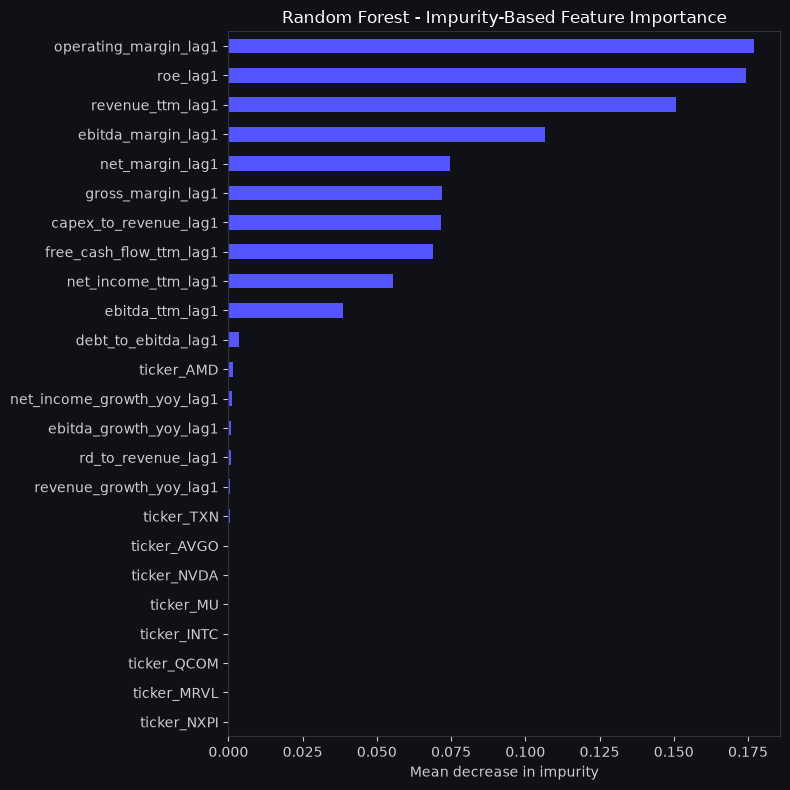

operating_margin_lag1         0.176928
roe_lag1                      0.174271
revenue_ttm_lag1              0.150863
ebitda_margin_lag1            0.106752
net_margin_lag1               0.074662
gross_margin_lag1             0.071888
capex_to_revenue_lag1         0.071595
free_cash_flow_ttm_lag1       0.068956
net_income_ttm_lag1           0.055534
ebitda_ttm_lag1               0.038649
debt_to_ebitda_lag1           0.003651
ticker_AMD                    0.001563
net_income_growth_yoy_lag1    0.001283
ebitda_growth_yoy_lag1        0.000847
rd_to_revenue_lag1            0.000831
revenue_growth_yoy_lag1       0.000674
ticker_TXN                    0.000453
ticker_AVGO                   0.000222
ticker_NVDA                   0.000111
ticker_MU                     0.000100
ticker_INTC                   0.000080
ticker_QCOM                   0.000074
ticker_MRVL                   0.000006
ticker_NXPI                   0.000005
dtype: float64


In [62]:
# importance from the model already fit
importances = pd.Series(rf_model.feature_importances_, index=features_rf).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot(kind='barh', ax=ax, color='#5555ff')
ax.invert_yaxis()
ax.set_title('Random Forest - Impurity-Based Feature Importance')
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout()
save(fig, '22_rf_feature_importance')
plt.show()

print(importances)

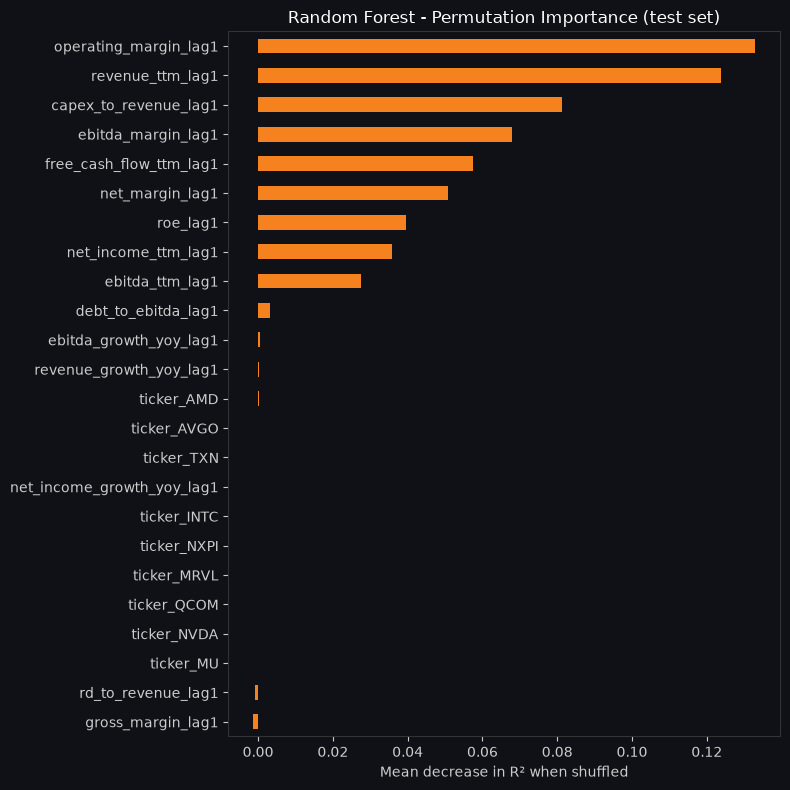

operating_margin_lag1         1.328638e-01
revenue_ttm_lag1              1.236706e-01
capex_to_revenue_lag1         8.124408e-02
ebitda_margin_lag1            6.783512e-02
free_cash_flow_ttm_lag1       5.753988e-02
net_margin_lag1               5.089408e-02
roe_lag1                      3.962951e-02
net_income_ttm_lag1           3.588107e-02
ebitda_ttm_lag1               2.749232e-02
debt_to_ebitda_lag1           3.260394e-03
ebitda_growth_yoy_lag1        4.190954e-04
revenue_growth_yoy_lag1       3.342559e-04
ticker_AMD                    2.787084e-04
ticker_AVGO                   1.004733e-04
ticker_TXN                    5.755443e-05
net_income_growth_yoy_lag1    4.873459e-05
ticker_INTC                   5.571527e-06
ticker_NXPI                   6.606947e-07
ticker_MRVL                  -2.326534e-06
ticker_QCOM                  -1.258116e-05
ticker_NVDA                  -6.736434e-05
ticker_MU                    -1.095514e-04
rd_to_revenue_lag1           -7.474100e-04
gross_margi

In [63]:
# permutation importance: shuffled features to see how much it affcts the model (confirms importance)

perm_result = permutation_importance(rf_model, x_test_rf, y_test_rf,n_repeats=30, random_state=42, n_jobs=-1)

perm_importances = pd.Series(perm_result.importances_mean, index=features_rf).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
perm_importances.plot(kind='barh', ax=ax, color='#f5821f')
ax.invert_yaxis()
ax.set_title('Random Forest - Permutation Importance (test set)')
ax.set_xlabel('Mean decrease in R² when shuffled')
plt.tight_layout()
save(fig, '23_rf_permutation_importance')
plt.show()

print(perm_importances)

In [64]:
# select features that are positive

selected_features_rf = perm_importances[perm_importances > 0].index.tolist()

print(f"Kept {len(selected_features_rf)} / {len(features_rf)} features:")
print(selected_features_rf)

Kept 18 / 24 features:
['operating_margin_lag1', 'revenue_ttm_lag1', 'capex_to_revenue_lag1', 'ebitda_margin_lag1', 'free_cash_flow_ttm_lag1', 'net_margin_lag1', 'roe_lag1', 'net_income_ttm_lag1', 'ebitda_ttm_lag1', 'debt_to_ebitda_lag1', 'ebitda_growth_yoy_lag1', 'revenue_growth_yoy_lag1', 'ticker_AMD', 'ticker_AVGO', 'ticker_TXN', 'net_income_growth_yoy_lag1', 'ticker_INTC', 'ticker_NXPI']


# 10. Random forest hyperparameter tuning

In [65]:
# refit on the importance-selected features
x_train_rf_sel= train_rf[selected_features_rf]
x_test_rf_sel = test_rf[selected_features_rf]

In [66]:
# TimeSeriesSplit to respect chronological order in the cross validation
tscv = TimeSeriesSplit(n_splits=5)

param_dist= {'n_estimators': [200, 300, 400, 500, 600],
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 1.0]}

rf_search= RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,n_iter=40,scoring='r2',cv=tscv,random_state=42,n_jobs=-1,verbose=1)

In [67]:
# fit model
rf_search.fit(x_train_rf_sel, y_train_rf)

print("Best params:", rf_search.best_params_)
print(f"Best CV R²: {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10}
Best CV R²: -3.5109


In [68]:
# evaluate the tuned model
best_rf = rf_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(x_test_rf_sel)

mae_rf_t = mean_absolute_error(y_test_rf, y_pred_rf_tuned)
rmse_rf_t = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf_tuned))
r2_rf_t = r2_score(y_test_rf, y_pred_rf_tuned)

print("Tuned Random Forest Performance (Original Scale)")
print(f"MAE: {mae_rf_t:,.0f}")
print(f"RMSE: {rmse_rf_t:,.0f}")
print(f"R²: {r2_rf_t:.4f}")

print("For comparison, original (untuned, full-feature) RF:")
print(f"MAE: {mae_rf:,.0f}")
print(f"RMSE: {rmse_rf:,.0f}")
print(f"R²: {r2_rf:.4f}")

Tuned Random Forest Performance (Original Scale)
MAE: 352,920,891,603
RMSE: 731,762,694,245
R²: 0.7107
For comparison, original (untuned, full-feature) RF:
MAE: 365,166,521,771
RMSE: 778,035,420,950
R²: 0.6730


In [69]:
# error per ticker

test_rf['y_pred'] = y_pred_rf
test_rf['abs_error'] = (test_rf[target_rf] - test_rf['y_pred']).abs()
test_rf['pct_error'] = (test_rf['abs_error'] / test_rf[target_rf]) * 100

print(test_rf.groupby('ticker')[[target_rf, 'y_pred', 'abs_error', 'pct_error']].mean()
      .sort_values('abs_error', ascending=False)
      .assign(**{target_rf: lambda x: x[target_rf].map('${:,.0f}'.format),
          'y_pred':  lambda x: x['y_pred'].map('${:,.0f}'.format),
          'abs_error': lambda x: x['abs_error'].map('${:,.0f}'.format),
          'pct_error': lambda x: x['pct_error'].map('{:.1f}%'.format)}))

                market_cap              y_pred           abs_error pct_error
ticker                                                                      
NVDA    $4,601,524,826,916  $2,340,279,613,357  $2,261,245,213,559     49.0%
AVGO    $1,660,005,724,950    $857,406,776,532    $802,598,948,418     47.2%
MU        $476,062,713,343    $188,542,912,821    $287,519,800,522     56.7%
AMD       $292,822,889,888    $172,056,341,147    $120,766,548,741     39.2%
ADI       $141,907,176,673     $86,918,900,975     $54,988,275,699     35.0%
INTC      $164,273,573,743    $134,704,125,777     $44,956,403,739     27.1%
MRVL       $89,257,410,254     $63,762,135,600     $32,778,234,451     34.1%
TXN       $170,019,413,176    $143,672,435,473     $26,346,977,703     15.1%
QCOM      $168,071,508,746    $153,185,085,556     $16,391,987,749      9.1%
NXPI       $53,293,034,324     $49,220,207,194      $4,072,827,130      7.7%


Not all companies have market caps equally financial driven. Other non financial factor may explain some companies market cap behaviour.
For example the highest errors are in NVDA, AVGO, MU, AMD, ADI. These are all companies whose recent valuations are driven by AI expectations and sentiment, specially  NVDA and AVGO, whose market caps increased above what financials could justify. 

# 11. XGBoost

In [70]:
# use the same selected_features_rf and same train/test split as tuned RF so they can be compared
# apply same Yeo-Johnson transformation used for LR/KNN

pt_xgb = PowerTransformer(method='yeo-johnson')

y_train_xgb_pt = pt_xgb.fit_transform(y_train_rf.values.reshape(-1, 1)).ravel()
y_test_xgb_pt  = pt_xgb.transform(y_test_rf.values.reshape(-1, 1)).ravel()

xgb_baseline = XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1, verbosity=0)
xgb_baseline.fit(x_train_rf_sel, y_train_xgb_pt)

# predict and inverse transform back to original scale
y_pred_xgb_pt = xgb_baseline.predict(x_test_rf_sel)
y_pred_xgb = pt_xgb.inverse_transform(y_pred_xgb_pt.reshape(-1, 1)).ravel()

mae_xgb  = mean_absolute_error(y_test_rf, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_rf, y_pred_xgb))
r2_xgb   = r2_score(y_test_rf, y_pred_xgb)

print("XGBoost Baseline Performance (Original Scale)")
print(f"MAE: {mae_xgb:,.0f}")
print(f"RMSE: {rmse_xgb:,.0f}")
print(f"R²: {r2_xgb:.4f}")

XGBoost Baseline Performance (Original Scale)
MAE: 489,565,226,513
RMSE: 1,099,218,528,022
R²: 0.3473


# 12. XGBboost Tuned

In [71]:
tscv = TimeSeriesSplit(n_splits=3)

param_dist_xgb = {'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1)

xgb_search.fit(x_train_rf_sel, y_train_xgb_pt)

print("Best params:", xgb_search.best_params_)
print(f"Best CV MAE: {-xgb_search.best_score_:,.0f}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV MAE: 1


In [72]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb_tuned_pt = best_xgb.predict(x_test_rf_sel)
y_pred_xgb_tuned = pt_xgb.inverse_transform(y_pred_xgb_tuned_pt.reshape(-1, 1)).ravel()

mae_xgb_t  = mean_absolute_error(y_test_rf, y_pred_xgb_tuned)
rmse_xgb_t = np.sqrt(mean_squared_error(y_test_rf, y_pred_xgb_tuned))
r2_xgb_t   = r2_score(y_test_rf, y_pred_xgb_tuned)

print("XGBoost Tuned Performance (Original Scale)")
print(f"MAE: {mae_xgb_t:,.0f}")
print(f"RMSE: {rmse_xgb_t:,.0f}")
print(f"R²: {r2_xgb_t:.4f}")

XGBoost Tuned Performance (Original Scale)
MAE: 575,693,926,472
RMSE: 1,278,311,153,881
R²: 0.1173


In [73]:
# error per ticker
test_rf['y_pred_xgb_tuned'] = y_pred_xgb_tuned
test_rf['abs_error_xgb'] = (test_rf[target_rf] - test_rf['y_pred_xgb_tuned']).abs()
test_rf['pct_error_xgb'] = (test_rf['abs_error_xgb'] / test_rf[target_rf]) * 100

print(test_rf.groupby('ticker')[[target_rf, 'y_pred_xgb_tuned', 'abs_error_xgb', 'pct_error_xgb']].mean()
      .sort_values('abs_error_xgb', ascending=False)
      .assign(**{
          target_rf:           lambda x: x[target_rf].map('${:,.0f}'.format),
          'y_pred_xgb_tuned':  lambda x: x['y_pred_xgb_tuned'].map('${:,.0f}'.format),
          'abs_error_xgb':     lambda x: x['abs_error_xgb'].map('${:,.0f}'.format),
          'pct_error_xgb':     lambda x: x['pct_error_xgb'].map('{:.1f}%'.format)}))

                market_cap  y_pred_xgb_tuned       abs_error_xgb pct_error_xgb
ticker                                                                        
NVDA    $4,601,524,826,916  $786,724,487,168  $3,814,800,339,748         83.0%
AVGO    $1,660,005,724,950  $470,681,124,864  $1,189,324,583,702         71.0%
MU        $476,062,713,343  $113,168,293,888    $362,894,421,503         62.7%
AMD       $292,822,889,888  $123,023,376,384    $169,799,515,552         56.3%
ADI       $141,907,176,673   $82,749,497,344     $59,157,681,377         38.3%
TXN       $170,019,413,176  $121,323,356,160     $48,696,052,920         28.4%
INTC      $164,273,573,743  $126,174,076,928     $42,247,992,471         23.8%
MRVL       $89,257,410,254   $56,065,241,088     $33,192,170,190         32.5%
QCOM      $168,071,508,746  $145,232,887,808     $30,457,169,064         17.6%
NXPI       $53,293,034,324   $46,923,694,080      $6,369,338,196         11.9%


In [74]:
test_rf['y_pred'].dtypes

dtype('float64')

# 13. Models comparison

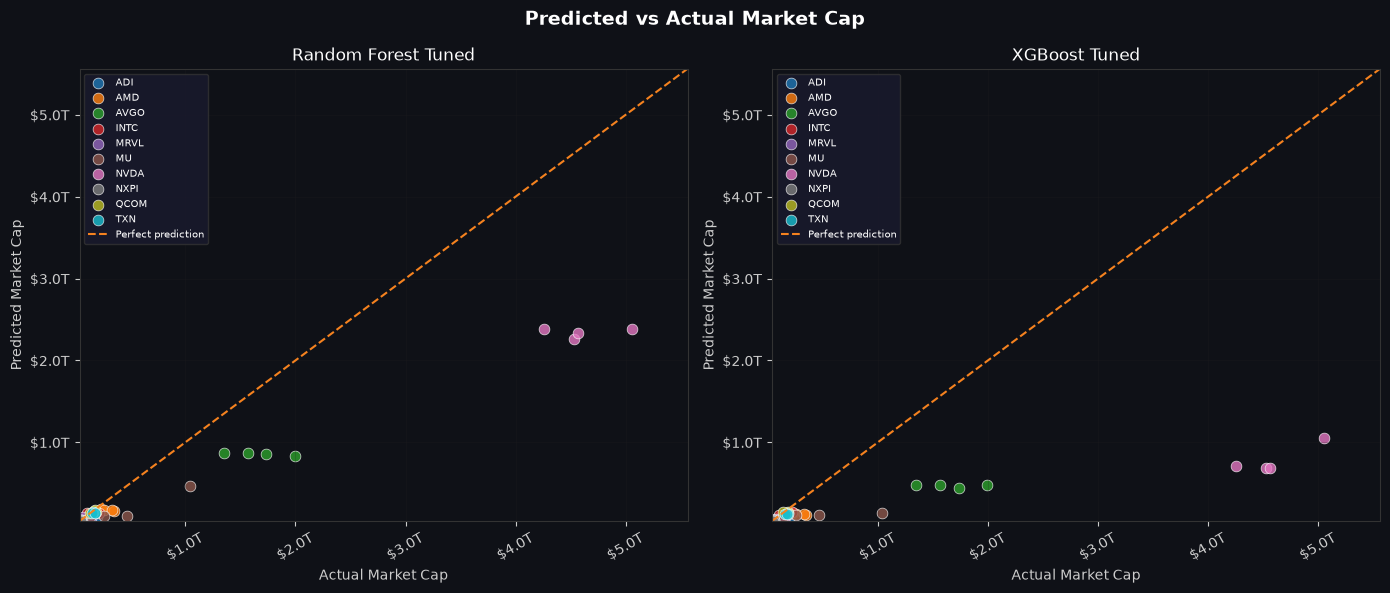

In [75]:
# scatterplot comparing predicted vs actual values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicted vs Actual Market Cap', fontsize=14, fontweight='bold')

tickers = test_rf['ticker'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(tickers)))
color_map = dict(zip(tickers, colors))

predictions = {'Random Forest Tuned': test_rf['y_pred'].values,'XGBoost Tuned':y_pred_xgb_tuned}

for ax, (title, y_pred) in zip(axes, predictions.items()):
    for ticker in tickers:
        mask = (test_rf['ticker'] == ticker).values
        ax.scatter(
            test_rf.loc[mask, target_rf],
            y_pred[mask],
            label=ticker,
            color=color_map[ticker],
            s=60, alpha=0.8, edgecolors='white', linewidths=0.5)

    lim_min = min(test_rf[target_rf].min(), y_pred.min()) * 0.9
    lim_max = max(test_rf[target_rf].max(), y_pred.max()) * 1.1
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='#f5821f', linestyle='--', lw=1.5, label='Perfect prediction')

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Actual Market Cap')
    ax.set_ylabel('Predicted Market Cap')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e12:.1f}T' if x >= 1e12 else f'${x/1e9:.0f}B'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e12:.1f}T' if x >= 1e12 else f'${x/1e9:.0f}B'))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
#save(fig, '24_predicted_vs_actual')
plt.show()

Ceiling effect in RF: everything gets predicted below $2.5T because the training data never contained market caps above that level for these companies (the AI boom happened in the test period). Both models hit this ceiling but RF does it consistently, while XGBoost does it erratically. That consistency is exactly why RF's R² is higher despite both models facing the same fundamental extrapolation problem.

In [76]:
# Model Comparison Table

comparison = {
    'Linear Regression':   {'R²': r2_orig,  'MAE': mae_orig,  'RMSE': rmse_orig},
    'KNN':                 {'R²': r2_kn,    'MAE': mae_kn,    'RMSE': rmse_kn},
    'Random Forest':       {'R²': r2_rf,    'MAE': mae_rf,    'RMSE': rmse_rf},
    'Random Forest Tuned': {'R²': r2_rf_t,  'MAE': mae_rf_t,  'RMSE': rmse_rf_t},
    'XGBoost':             {'R²': r2_xgb,   'MAE': mae_xgb,   'RMSE': rmse_xgb},
    'XGBoost Tuned':       {'R²': r2_xgb_t, 'MAE': mae_xgb_t, 'RMSE': rmse_xgb_t},}

comparison_df = pd.DataFrame(comparison).T
comparison_df.index.name = 'Model'

# format for display
display_df = comparison_df.copy()
display_df['R²']   = comparison_df['R²'].map('{:.4f}'.format)
display_df['MAE']  = comparison_df['MAE'].map('${:,.0f}'.format)
display_df['RMSE'] = comparison_df['RMSE'].map('${:,.0f}'.format)

print(display_df.to_string())

                         R²               MAE                RMSE
Model                                                            
Linear Regression    0.1303  $609,336,707,814  $1,268,880,217,678
KNN                  0.4752  $481,537,958,338    $985,628,981,296
Random Forest        0.6730  $365,166,521,771    $778,035,420,950
Random Forest Tuned  0.7107  $352,920,891,603    $731,762,694,245
XGBoost              0.3473  $489,565,226,513  $1,099,218,528,022
XGBoost Tuned        0.1173  $575,693,926,472  $1,278,311,153,881


In [77]:
print("XGBoost Baseline features:", xgb_baseline.n_features_in_)
print("XGBoost Tuned features:   ", best_xgb.n_features_in_)
print("x_train_rf_sel shape:     ", x_train_rf_sel.shape[1])
print("features_rf length:       ", len(features_rf))

XGBoost Baseline features: 18
XGBoost Tuned features:    18
x_train_rf_sel shape:      18
features_rf length:        24


In [78]:
# check overfitting

models = {'Linear Regression': (lr,x_train[feature_cols], y_train,x_test[feature_cols], y_test,True),
    'KNN':(knn,x_train_kn_scaled,y_train_kn, x_test_kn_scaled,y_test_kn, True),
    'RF Baseline': (rf_model,x_train_rf,y_train_rf, x_test_rf,y_test_rf, False),
    'RF Tuned':(best_rf,x_train_rf_sel,y_train_rf, x_test_rf_sel,y_test_rf, False),
    'XGBoost Baseline':(xgb_baseline,  x_train_rf_sel,y_train_rf, x_test_rf_sel,y_test_rf, True),
    'XGBoost Tuned':(best_xgb,x_train_rf_sel,y_train_rf, x_test_rf_sel,y_test_rf, True),}

rows = []
for name, (model, x_tr, y_tr, x_te, y_te, use_pt) in models.items():

    y_pred_train= model.predict(x_tr)
    y_pred_test= model.predict(x_te)

    if use_pt:
        y_pred_train = pt.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()
        y_pred_test  = pt.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

    r2_train= r2_score(y_tr, y_pred_train)
    r2_test= r2_score(y_te, y_pred_test)

    rows.append({
        'Model':name,
        'Train R²':round(r2_train, 4),
        'Test R²':round(r2_test,  4),
        'Gap':round(r2_train - r2_test, 4)})

overfit_df = pd.DataFrame(rows).set_index('Model')
print(overfit_df.to_string())

                   Train R²  Test R²     Gap
Model                                       
Linear Regression    0.0712   0.1303 -0.0591
KNN                  1.0000   0.4752  0.5248
RF Baseline          0.9935   0.6730  0.3205
RF Tuned             0.9698   0.7107  0.2590
XGBoost Baseline     1.0000   0.3473  0.6527
XGBoost Tuned        0.6622   0.1173  0.5449


In [79]:
# save fs to the clean data defined in config:
fs.to_csv(cfg['clean']['feature_engineering'], index=False)

print(f"File saved to: {cfg['clean']['feature_engineering']}")

File saved to: ../data/clean/feature_selection.csv


In [81]:
def get_train_r2(model, x_tr, y_tr, use_pt):
    y_pred_tr = model.predict(x_tr)
    if use_pt:
        y_pred_tr = pt.inverse_transform(y_pred_tr.reshape(-1, 1)).ravel()
    return round(r2_score(y_tr, y_pred_tr), 4)

train_r2_lr= get_train_r2(lr,x_train[feature_cols], y_train,    True)
train_r2_kn= get_train_r2(knn,x_train_kn_scaled,y_train_kn, True)
train_r2_rf= get_train_r2(rf_model,x_train_rf,y_train_rf, False)
train_r2_rf_t= get_train_r2(best_rf,x_train_rf_sel,y_train_rf, False)
train_r2_xgb= get_train_r2(xgb_baseline,x_train_rf_sel,y_train_rf, True)
train_r2_xgb_t= get_train_r2(best_xgb,x_train_rf_sel,y_train_rf, True)

ml1_export = pd.DataFrame({
    'Model':['Linear Regression', 'KNN', 'Random Forest', 'Random Forest Tuned', 'XGBoost', 'XGBoost Tuned'],
    'Features': ['Financials'] * 6,
    'Train R²': [train_r2_lr, train_r2_kn, train_r2_rf, train_r2_rf_t, train_r2_xgb, train_r2_xgb_t],
    'Test R²':  [r2_orig,r2_kn, r2_rf, r2_rf_t,r2_xgb,r2_xgb_t],
    'MAE':[mae_orig,mae_kn,mae_rf, mae_rf_t,mae_xgb,mae_xgb_t],
    'RMSE':[rmse_orig,rmse_kn,rmse_rf,rmse_rf_t,rmse_xgb,rmse_xgb_t],}).set_index('Model')

ml1_export['Gap'] = ml1_export['Train R²'] - ml1_export['Test R²']
ml1_export.to_csv(cfg['clean']['ml1_results'])
print(ml1_export.to_string())
print("Saved to", cfg['clean']['ml1_results'])

                       Features  Train R²   Test R²           MAE          RMSE       Gap
Model                                                                                    
Linear Regression    Financials    0.0712  0.130263  6.093367e+11  1.268880e+12 -0.059063
KNN                  Financials    1.0000  0.475224  4.815380e+11  9.856290e+11  0.524776
Random Forest        Financials    0.9935  0.673002  3.651665e+11  7.780354e+11  0.320498
Random Forest Tuned  Financials    0.9698  0.710741  3.529209e+11  7.317627e+11  0.259059
XGBoost              Financials    1.0000  0.347298  4.895652e+11  1.099219e+12  0.652702
XGBoost Tuned        Financials    0.6622  0.117286  5.756939e+11  1.278311e+12  0.544914
Saved to ../data/clean/ml1_results.csv
